# Network-Enhanced FinRL Ensemble Stock Trading

This notebook extends the ICAIF-style FinRL ensemble stock-trading framework by adding rolling correlation-network features to the reinforcement learning state space.

The original model uses prices, holdings, cash balance, and technical indicators.  
This extension adds graph-based information describing the position of each stock within the market correlation network.

# Content

* [1. Problem Definition](#0)
* [2. Getting Started - Load Python packages](#1)
    * [2.1. Install Packages](#1.1)    
    * [2.2. Check Additional Packages](#1.2)
    * [2.3. Import Packages](#1.3)
    * [2.4. Create Folders](#1.4)
* [3. Download Data](#2)
* [4. Preprocess Data](#3)        
    * [4.1. Technical Indicators](#3.1)
    * [4.2. Perform Feature Engineering](#3.2)
* [5.Build Environment](#4)  
    * [5.1. Training & Trade Data Split](#4.1)
    * [5.2. User-defined Environment](#4.2)   
    * [5.3. Initialize Environment](#4.3)    
* [6.Implement DRL Algorithms](#5)  
* [7.Backtesting Performance](#6)  
    * [7.1. BackTestStats](#6.1)
    * [7.2. BackTestPlot](#6.2)   
    * [7.3. Baseline Stats](#6.3)   
    * [7.3. Compare to Stock Market Index](#6.4)             

<a id='0'></a>
# Part 1. Problem Definition


The original ICAIF framework models stock trading as a Markov Decision Process. The agent observes portfolio information and market indicators, takes buy/sell/hold actions, and receives rewards based on changes in portfolio value.

In this notebook, the MDP structure is kept unchanged. The extension is made through the state space: in addition to the original technical indicators, the agent also observes rolling correlation-network features.

The algorithm is trained using Deep Reinforcement Learning (DRL) algorithms and the components of the reinforcement learning environment are:


* Action: The action space describes the allowed actions that the agent interacts with the
environment. Normally, a ∈ A includes three actions: a ∈ {−1, 0, 1}, where −1, 0, 1 represent
selling, holding, and buying one stock. Also, an action can be carried upon multiple shares. We use
an action space {−k, ..., −1, 0, 1, ..., k}, where k denotes the number of shares. For example, "Buy
10 shares of AAPL" or "Sell 10 shares of AAPL" are 10 or −10, respectively

* Reward function: r(s, a, s′) is the incentive mechanism for an agent to learn a better action. The change of the portfolio value when action a is taken at state s and arriving at new state s',  i.e., r(s, a, s′) = v′ − v, where v′ and v represent the portfolio
values at state s′ and s, respectively

* State: The state space describes the observations that the agent receives from the environment. Just as a human trader needs to analyze various information before executing a trade, so
our trading agent observes many different features to better learn in an interactive environment. <-- This is where our extension will be implemented

* Environment: Dow 30 consituents


The data of the single stock that we will be using for this case study is obtained from Yahoo Finance API. The data contains Open-High-Low-Close price and volume.



<a id='1'></a>
# Part 2. Getting Started- Load Python Packages

<a id='1.1'></a>
## 2.1. Install all the packages through FinRL library


In [291]:
'''
#This is the block of code required to install the required packages in colab. 
# ## install finrl library
!pip install wrds
!pip install swig
!pip install -q condacolab
import condacolab
condacolab.install()
!apt-get update -y -qq && apt-get install -y -qq cmake libopenmpi-dev python3-dev zlib1g-dev libgl1-mesa-glx swig
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git
'''


'\n#This is the block of code required to install the required packages in colab. \n# ## install finrl library\n!pip install wrds\n!pip install swig\n!pip install -q condacolab\nimport condacolab\ncondacolab.install()\n!apt-get update -y -qq && apt-get install -y -qq cmake libopenmpi-dev python3-dev zlib1g-dev libgl1-mesa-glx swig\n!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git\n'


<a id='1.2'></a>
## 2.2. Check if the additional packages needed are present, if not install them. 
* Yahoo Finance API
* pandas
* numpy
* matplotlib
* stockstats
* OpenAI gym
* stable-baselines
* tensorflow
* pyfolio

<a id='1.3'></a>
## 2.3. Import Packages

In [292]:
import warnings
warnings.filterwarnings("ignore")

In [293]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
# matplotlib.use('Agg')
import datetime

%matplotlib inline
from finrl.config_tickers import DOW_30_TICKER
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent,DRLEnsembleAgent
from finrl.plot import backtest_stats, backtest_plot, get_daily_return, get_baseline

from pprint import pprint

import sys
sys.path.append("../FinRL-Library")

import itertools

In [294]:
import random
import torch
import src.config as cfg


random.seed(cfg.SEED)
np.random.seed(cfg.SEED)
torch.manual_seed(cfg.SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(cfg.SEED)
    torch.cuda.manual_seed_all(cfg.SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [295]:
print(cfg.DEBUG)
print(cfg.TRAIN_START_DATE)
print(cfg.TRAIN_END_DATE)
print(cfg.TEST_START_DATE)
print(cfg.TEST_END_DATE)

True
2017-01-01
2018-01-01
2018-01-02
2019-06-01


<a id='1.4'></a>
## 2.4. Create Folders

In [296]:
import os
from finrl.main import check_and_make_directories
from finrl.config import (
    DATA_SAVE_DIR,
    TRAINED_MODEL_DIR,
    TENSORBOARD_LOG_DIR,
    RESULTS_DIR,
    INDICATORS,
    TRAIN_START_DATE,
    TRAIN_END_DATE,
    TEST_START_DATE,
    TEST_END_DATE,
    TRADE_START_DATE,
    TRADE_END_DATE,
)

check_and_make_directories([DATA_SAVE_DIR, TRAINED_MODEL_DIR, TENSORBOARD_LOG_DIR, RESULTS_DIR])

<a id='2'></a>
# Part 3. Download Data
Yahoo Finance is a website that provides stock data, financial news, financial reports, etc. All the data provided by Yahoo Finance is free.
* FinRL uses a class **YahooDownloader** to fetch data from Yahoo Finance API
* Call Limit: Using the Public API (without authentication), you are limited to 2,000 requests per hour per IP (or up to a total of 48,000 requests a day).




-----
class YahooDownloader:
    Provides methods for retrieving daily stock data from
    Yahoo Finance API

    Attributes
    ----------
        start_date : str
            start date of the data (modified from config.py)
        end_date : str
            end date of the data (modified from config.py)
        ticker_list : list
            a list of stock tickers (modified from config.py)

    Methods
    -------
    fetch_data()
        Fetches data from yahoo API


In [297]:
if cfg.EXPLORATION_MODE:
    print(DOW_30_TICKER)

## 3.1 Experiment switches

This section controls the experimental specification.

The key comparison is between:

1. **Technicals-only baseline**: the original FinRL-style state space. (Specification A)
2. **Node-only Network-extended model**: the original state space plus node-level. (Specification B)
3. **Node-only Network-extended model**: the state space of 2 plus the market-level network features (Specification C)

The flags `USE_NETWORK` and `USE_MARKET_NETWORK` determine which version is run.

In [298]:
# ============================================================
# Experiment configuration
# ============================================================
# This block defines the experiment setup.
#
# The original ICAIF-style model uses technical indicators only.
# The extension activates additional network-based state variables
# computed from rolling return correlations.

# Set debug=True for a fast validation test. Set debug=False for the full run.
# USE_NETWORK controls node-level graph features.
# USE_MARKET_NETWORK controls market-level graph features.
# ============================================================



import os
import time

if os.path.exists(cfg.CACHE_PATH) and os.path.exists(cfg.RAW_CACHE_PATH):
    print("Loading cached data...")
    processed = pd.read_pickle(cfg.CACHE_PATH)
    df = pd.read_pickle(cfg.RAW_CACHE_PATH)
else:
    print("Processing data from scratch...")
    all_data = []

    for tic in DOW_30_TICKER:
        success = False
        for attempt in range(3):  # retry up to 3 times
            try:
                print(f"Downloading {tic}, attempt {attempt+1}")
                temp = YahooDownloader(
                    start_date=cfg.TRAIN_START_DATE,
                    end_date=cfg.TEST_END_DATE,   # <-- fix: use full horizon
                    ticker_list=[tic]
                ).fetch_data()

                if temp is not None and len(temp) > 0:
                    all_data.append(temp)
                    success = True
                    break
            except Exception as e:
                print(f"Error downloading {tic}: {e}")
            time.sleep(3)

        if not success:
            print(f"WARNING: {tic} failed and will be skipped")

    df = pd.concat(all_data, ignore_index=True)

    if cfg.DEBUG:
        # check missing tickers
        downloaded = set(df["tic"].unique())
        missing = set(DOW_30_TICKER) - downloaded
        print("Missing tickers:", missing)

    fe = FeatureEngineer(
        use_technical_indicator=True,
        tech_indicator_list=cfg.INDICATORS,
        use_turbulence=True,
        user_defined_feature=False
    )

    processed = fe.preprocess_data(df)
    processed = processed.copy().fillna(0).replace(np.inf, 0)


    # save AFTER all preprocessing
    df.to_pickle(cfg.RAW_CACHE_PATH)
    processed.to_pickle(cfg.CACHE_PATH)

Loading cached data...


In [299]:
if cfg.EXPLORATION_MODE:
    processed

In [300]:
if cfg.DEBUG:
    expected_tickers = set(DOW_30_TICKER)
    downloaded_tickers = set(df["tic"].unique())

    missing_tickers = expected_tickers - downloaded_tickers

    print("Expected:", len(expected_tickers))
    print("Downloaded:", len(downloaded_tickers))
    print("Missing:", missing_tickers)

Expected: 30
Downloaded: 30
Missing: set()


In [301]:
if cfg.EXPLORATION_MODE:
    print(df.head())
    print(df.tail())
    print(df.shape)
    print(df.sort_values(['date','tic']).head())
    print(len(df.tic.unique()))
    print(df.tic.value_counts())

# Part 4. Network Feature Engineering

This section implements the main extension of the project.

The original FinRL ensemble model uses asset-level market information such as prices, holdings, and technical indicators. Here, we add information about the cross-sectional structure of the market by constructing rolling stock-correlation networks.

Each stock is treated as a node. Edges represent sufficiently strong correlations between stock returns.The node-level features are merged into the FinRL observation space after a one-day shift, so the agent only receives information available before the trading decision.



In [302]:
price_panel = processed.pivot(index="date", columns="tic", values="close")

price_panel = price_panel.sort_index()


print("Shape of the Price Panel: ", price_panel.shape)
print("First 5 rows of the Price Panel: ", price_panel.head())

if cfg.EXPLORATION_MODE:
    print("Number of stocks:", price_panel.shape[1])
    print("Missing values:", price_panel.isna().sum().sum())
    print("NAs: ", price_panel.isna().sum().sort_values(ascending=False).head())

Shape of the Price Panel:  (606, 30)
First 5 rows of the Price Panel:  tic              AAPL        AMGN       AMZN        AXP          BA  \
date                                                                  
2017-01-03  26.721239  113.276253  37.683498  65.994888  145.533676   
2017-01-04  26.691322  114.884514  37.859001  67.076752  147.063461   
2017-01-05  26.827063  114.967171  39.022499  66.249939  147.146927   
2017-01-06  27.126144  117.822929  39.799500  66.381889  147.508499   
2017-01-09  27.374599  119.371063  39.846001  66.724945  146.785309   

tic               CAT        CRM       CSCO        CVX         DIS  ...  \
date                                                                ...   
2017-01-03  76.283112  69.340385  22.882046  78.751358   98.492439  ...   
2017-01-04  75.942238  71.561935  22.746021  78.731323   99.755180  ...   
2017-01-05  75.479637  71.552109  22.798918  78.390503   99.699463  ...   
2017-01-06  75.512100  72.544945  22.844259  78.076431  

In [303]:
returns= price_panel.pct_change()

returns=returns.dropna()

print(returns)

rolling_corr= returns.rolling(window=cfg.REBALANCE_WINDOW).corr()
rolling_corr=rolling_corr.dropna()
if cfg.EXPLORATION_MODE:
    print("First 5 rows of the returns", returns.head())
    print("First 5 rows of the rolling correlation",rolling_corr.head())

tic             AAPL      AMGN      AMZN       AXP        BA       CAT  \
date                                                                     
2017-01-04 -0.001120  0.014198  0.004657  0.016393  0.010512 -0.004469   
2017-01-05  0.005086  0.000719  0.030732 -0.012326  0.000568 -0.006091   
2017-01-06  0.011149  0.024840  0.019912  0.001992  0.002457  0.000430   
2017-01-09  0.009159  0.013139  0.001168  0.005168 -0.004903 -0.007201   
2017-01-10  0.001009 -0.000504 -0.001280  0.010414  0.004737  0.015806   
...              ...       ...       ...       ...       ...       ...   
2019-05-24 -0.003841 -0.004822  0.004296  0.009119  0.012409  0.005235   
2019-05-28 -0.004135 -0.014187  0.007212 -0.011212 -0.000056 -0.010659   
2019-05-29 -0.004769  0.001954 -0.009388 -0.009816 -0.017133 -0.000905   
2019-05-30  0.005187 -0.000828 -0.001578 -0.002307  0.003068  0.002963   
2019-05-31 -0.018116 -0.013843 -0.022711 -0.017389 -0.023609 -0.016661   

tic              CRM      CSCO       

# Granger Introduction

In [304]:
returns

tic,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT
date,,,,,,,,,,,,,,,,,,,,,
2017-01-04,-0.001120,0.014198,0.004657,0.016393,0.010512,-0.004469,0.032038,-0.005945,-0.000254,0.012821,...,-0.004474,0.020970,0.023331,0.003562,0.006775,-0.005377,0.002849,0.008176,-0.001099,0.005826
2017-01-05,0.005086,0.000719,0.030732,-0.012326,0.000568,-0.006091,-0.000137,0.002326,-0.004329,-0.000559,...,0.000000,-0.000188,-0.025386,0.006627,-0.000796,-0.015967,0.001667,0.011728,0.002201,0.002172
2017-01-06,0.011149,0.024840,0.019912,0.001992,0.002457,0.000430,0.013876,0.001989,-0.004007,0.014900,...,0.008668,0.016020,0.013368,-0.000352,0.010175,-0.000507,0.001418,0.013812,-0.014835,-0.013726
2017-01-09,0.009159,0.013139,0.001168,0.005168,-0.004903,-0.007201,0.002168,-0.001654,-0.008558,-0.005689,...,-0.003183,-0.009831,0.040543,-0.007409,-0.000824,-0.008032,-0.002832,-0.005595,-0.010890,0.006592
2017-01-10,0.001009,-0.000504,-0.001280,0.010414,0.004737,0.015806,0.000271,0.006627,-0.007597,0.000185,...,-0.000319,-0.005058,-0.007550,-0.010782,0.000430,-0.001193,-0.002285,-0.005383,0.001518,-0.006986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-05-24,-0.003841,-0.004822,0.004296,0.009119,0.012409,0.005235,0.005204,0.003322,0.007127,0.000452,...,0.000475,-0.005808,-0.014730,-0.000656,0.000348,0.006805,0.004584,0.006997,0.007644,0.007952
2019-05-28,-0.004135,-0.014187,0.007212,-0.011212,-0.000056,-0.010659,0.004401,-0.008093,-0.003370,-0.001280,...,-0.000634,-0.011685,-0.012539,-0.020902,-0.008567,-0.011220,-0.022493,0.006578,-0.009946,-0.002435
2019-05-29,-0.004769,0.001954,-0.009388,-0.009816,-0.017133,-0.000905,-0.014821,-0.013907,-0.013017,-0.007917,...,-0.009670,-0.028694,-0.020861,-0.002584,-0.001382,-0.008272,0.001405,-0.005986,-0.009365,-0.002929


In [305]:
import src.graphs.granger as granger
window = cfg.REBALANCE_WINDOW
maxlag = cfg.MAXLAG
boolean =False
pickle_path = cfg.GRANGER_PICKLE_PATH
alpha = cfg.GRANGER_ALPHA

adjacency_matrices=granger.build_or_load_adjacency_matrices_granger(returns,pickle_path,window,maxlag)


Loading existing Granger adjacency matrices...


In [306]:
processed

,date,close,high,low,open,volume,tic,day,macd,rsi_30,cci_30,dx_30,turbulence
0,2017-01-03,26.721239,26.762650,26.401459,26.640719,115127600,AAPL,1,0.000000,0.000000,66.666667,100.000000,0.000000
1,2017-01-03,113.276253,113.479166,110.563274,111.119401,3640900,AMGN,1,0.000000,0.000000,66.666667,100.000000,0.000000
2,2017-01-03,37.683498,37.938000,37.384998,37.896000,70422000,AMZN,1,0.000000,0.000000,66.666667,100.000000,0.000000
3,2017-01-03,65.994888,66.345227,65.460623,65.592001,5853900,AXP,1,0.000000,0.000000,66.666667,100.000000,0.000000
4,2017-01-03,145.533676,145.691289,143.901909,144.912492,3426100,BA,1,0.000000,0.000000,66.666667,100.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18175,2019-05-31,125.011063,125.663723,124.083590,124.641785,1405400,TRV,4,1.468440,60.253836,47.397940,10.847505,34.838006
18176,2019-05-31,213.554688,215.162081,211.505687,213.687160,3285700,UNH,4,1.572988,49.621701,51.918858,6.103143,34.838006
18177,2019-05-31,153.516403,154.277660,152.783692,153.116747,5079000,V,4,0.809399,55.073389,-16.750265,3.559971,34.838006
18178,2019-05-31,35.988186,36.709936,35.928592,36.478183,29916600,VZ,4,-0.042710,40.327920,-203.317466,25.071175,34.838006


# Reshaping of returns and adding to the Processed dataframe

In [307]:
returns_long=(returns.reset_index().melt(id_vars="date",var_name="tic",value_name="returns"))
processed=processed.merge(returns_long,on=["date","tic"],how="left")
processed=processed.dropna(subset=["returns"])

In [308]:

print(processed["returns"].isna().sum())
processed[["date", "tic", "returns"]].sample(5)

0


,date,tic,returns
16364,2019-03-06,JNJ,0.002306
11269,2018-06-29,MRK,0.006633
2219,2017-04-19,WMT,0.002436
7077,2017-12-07,V,0.015127
9467,2018-04-05,MCD,0.013727


In [309]:
import src.GNN.graph_dataset as GNN_data
from torch_geometric.data import Data

ticker_list = sorted(processed["tic"].unique())
#Validation test
if cfg.DEBUG:
    date = list(adjacency_matrices.keys())[36]
    adjacency_matrix=adjacency_matrices[date]
    graph= GNN_data.build_graph_snapshot(date,processed,adjacency_matrix,ticker_list,node_feature_cols=["returns"])
    print(graph.num_nodes)
    print(graph.num_edges)
    print(graph.x.shape)
    print(graph.edge_index.shape)
    for i in range(5):
        print(
            ticker_list[i],
            graph.x[i].item()
        )
    processed[
        (processed["date"] == graph.date)
    ].set_index("tic").loc[ticker_list[:5], "returns"]

30
81
torch.Size([30, 1])
torch.Size([2, 81])
AAPL -0.0016892952844500542
AMGN -0.002702713245525956
AMZN 0.0024160491302609444
AXP 0.0002587962953839451
BA -0.002566102659329772


In [310]:
#graphs= GNN_data.build_pyg_graph_dataset(processed, adjacency_matrices,ticker_list,node_feature_cols=["macd","rsi_30","cci_30","returns"])
graphs= GNN_data.build_pyg_graph_dataset(processed, adjacency_matrices,ticker_list,node_feature_cols=["returns"])
graphs

[Data(x=[30, 1], edge_index=[2, 59], date='2017-04-05', tickers=[30], num_tickers=30, feature_names=[1]),
 Data(x=[30, 1], edge_index=[2, 59], date='2017-04-06', tickers=[30], num_tickers=30, feature_names=[1]),
 Data(x=[30, 1], edge_index=[2, 61], date='2017-04-07', tickers=[30], num_tickers=30, feature_names=[1]),
 Data(x=[30, 1], edge_index=[2, 65], date='2017-04-10', tickers=[30], num_tickers=30, feature_names=[1]),
 Data(x=[30, 1], edge_index=[2, 64], date='2017-04-11', tickers=[30], num_tickers=30, feature_names=[1]),
 Data(x=[30, 1], edge_index=[2, 62], date='2017-04-12', tickers=[30], num_tickers=30, feature_names=[1]),
 Data(x=[30, 1], edge_index=[2, 65], date='2017-04-13', tickers=[30], num_tickers=30, feature_names=[1]),
 Data(x=[30, 1], edge_index=[2, 65], date='2017-04-17', tickers=[30], num_tickers=30, feature_names=[1]),
 Data(x=[30, 1], edge_index=[2, 65], date='2017-04-18', tickers=[30], num_tickers=30, feature_names=[1]),
 Data(x=[30, 1], edge_index=[2, 56], date='201

In [311]:
from src.GNN.models import SimpleGCNEncoder

model = SimpleGCNEncoder(
    in_channels=graph.x.shape[1],
    hidden_channels=16,
    embedding_dim=8,
)

embeddings = model(graph)

print(embeddings.shape)
print(embeddings[:5])

torch.Size([30, 8])
tensor([[ 2.7332e-05, -2.6930e-04, -9.9513e-04,  2.0152e-04, -1.3356e-03,
         -1.5268e-03,  3.1697e-04, -9.3637e-04],
        [-5.9745e-04,  8.9059e-04, -1.3811e-03,  1.5173e-04, -7.1599e-04,
         -1.8425e-03, -1.7714e-04, -6.3472e-05],
        [ 4.4191e-04, -8.4968e-04,  1.3735e-04,  6.1934e-05, -6.1366e-04,
          1.6795e-05,  3.8907e-04, -7.3779e-04],
        [ 2.5655e-04, -6.3177e-04, -5.6150e-04,  1.6226e-04, -1.1854e-03,
         -9.6640e-04,  4.1302e-04, -9.9744e-04],
        [-4.8074e-04,  6.7787e-04, -1.2907e-03,  1.5742e-04, -8.0806e-04,
         -1.7556e-03, -9.0180e-05, -2.1028e-04]], grad_fn=<SliceBackward0>)


In [312]:
embeddings_list = []

for graph in graphs:
    embedding = model(graph)
    embeddings_list.append(embedding)

print(f"Successfully processed {len(embeddings_list)} graphs.")

Successfully processed 542 graphs.


In [313]:
embeddings_df= GNN_data.embeddings_to_dataframe(graphs, embeddings_list)
processed_gnn= processed.merge(embeddings_df, on=["date","tic"],how="left")
processed_gnn

,date,close,high,low,open,volume,tic,day,macd,rsi_30,...,turbulence,returns,gnn_emb_0,gnn_emb_1,gnn_emb_2,gnn_emb_3,gnn_emb_4,gnn_emb_5,gnn_emb_6,gnn_emb_7
0,2017-01-04,26.691322,26.804052,26.629207,26.652213,84472400,AAPL,2,-0.000671,0.000000,...,0.000000,-0.001120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-01-04,114.884514,115.523309,114.057851,114.298331,3945900,AMGN,2,0.036083,100.000000,...,0.000000,0.014198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2017-01-04,37.859001,37.984001,37.709999,37.919498,50210000,AMZN,2,0.003938,100.000000,...,0.000000,0.004657,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2017-01-04,67.076752,67.331831,66.021252,66.197172,4635800,AXP,2,0.024273,100.000000,...,0.000000,0.016393,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2017-01-04,147.063461,147.629019,146.312478,146.312478,3189800,BA,2,0.034322,100.000000,...,0.000000,0.010512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18145,2019-05-31,125.011063,125.663723,124.083590,124.641785,1405400,TRV,4,1.468440,60.253836,...,34.838006,-0.001098,-0.002376,0.003542,-0.005493,0.000603,-0.002848,-0.007328,-0.000704,-0.000252
18146,2019-05-31,213.554688,215.162081,211.505687,213.687160,3285700,UNH,4,1.572988,49.621701,...,34.838006,-0.006981,-0.003460,0.005158,-0.007999,0.000879,-0.004147,-0.010671,-0.001026,-0.000368
18147,2019-05-31,153.516403,154.277660,152.783692,153.116747,5079000,V,4,0.809399,55.073389,...,34.838006,-0.008786,-0.001942,0.002895,-0.004490,0.000493,-0.002328,-0.005990,-0.000576,-0.000206
18148,2019-05-31,35.988186,36.709936,35.928592,36.478183,29916600,VZ,4,-0.042710,40.327920,...,34.838006,-0.043639,-0.004472,0.006666,-0.010337,0.001136,-0.005359,-0.013790,-0.001326,-0.000475


In [314]:
gnn_cols = [col for col in processed_gnn.columns if col.startswith("gnn_emb_")]

print(gnn_cols)
print(processed_gnn[gnn_cols].isna().sum())
print(processed_gnn[["date", "tic"] + gnn_cols].head())

['gnn_emb_0', 'gnn_emb_1', 'gnn_emb_2', 'gnn_emb_3', 'gnn_emb_4', 'gnn_emb_5', 'gnn_emb_6', 'gnn_emb_7']
gnn_emb_0    1890
gnn_emb_1    1890
gnn_emb_2    1890
gnn_emb_3    1890
gnn_emb_4    1890
gnn_emb_5    1890
gnn_emb_6    1890
gnn_emb_7    1890
dtype: int64
         date   tic  gnn_emb_0  gnn_emb_1  gnn_emb_2  gnn_emb_3  gnn_emb_4  \
0  2017-01-04  AAPL        NaN        NaN        NaN        NaN        NaN   
1  2017-01-04  AMGN        NaN        NaN        NaN        NaN        NaN   
2  2017-01-04  AMZN        NaN        NaN        NaN        NaN        NaN   
3  2017-01-04   AXP        NaN        NaN        NaN        NaN        NaN   
4  2017-01-04    BA        NaN        NaN        NaN        NaN        NaN   

   gnn_emb_5  gnn_emb_6  gnn_emb_7  
0        NaN        NaN        NaN  
1        NaN        NaN        NaN  
2        NaN        NaN        NaN  
3        NaN        NaN        NaN  
4        NaN        NaN        NaN  


In [315]:
valid_gnn_dates = embeddings_df["date"].unique()

processed_gnn = processed_gnn[
    processed_gnn["date"].isin(valid_gnn_dates)
].copy()

In [316]:
processed_gnn[gnn_cols].isna().sum()
processed_gnn["date"].min(), processed_gnn["date"].max()

('2017-04-05', '2019-05-31')

# Stop

In [317]:
processed= granger.add_granger_network_features(processed,adjacency_matrices)
processed

,date,close,high,low,open,volume,tic,day,macd,rsi_30,cci_30,dx_30,turbulence,returns,granger_in_degree,granger_out_degree,granger_pagerank,Average_granger_in_degree,Average_granger_out_degree,Average_granger_pagerank
0,2017-01-04,26.691322,26.804052,26.629207,26.652213,84472400,AAPL,2,-0.000671,0.000000,66.666667,100.000000,0.000000,-0.001120,0.0,0.0,0.000000,0.0,0.0,0.000000
1,2017-01-04,114.884514,115.523309,114.057851,114.298331,3945900,AMGN,2,0.036083,100.000000,66.666667,100.000000,0.000000,0.014198,0.0,0.0,0.000000,0.0,0.0,0.000000
2,2017-01-04,37.859001,37.984001,37.709999,37.919498,50210000,AMZN,2,0.003938,100.000000,66.666667,100.000000,0.000000,0.004657,0.0,0.0,0.000000,0.0,0.0,0.000000
3,2017-01-04,67.076752,67.331831,66.021252,66.197172,4635800,AXP,2,0.024273,100.000000,66.666667,100.000000,0.000000,0.016393,0.0,0.0,0.000000,0.0,0.0,0.000000
4,2017-01-04,147.063461,147.629019,146.312478,146.312478,3189800,BA,2,0.034322,100.000000,66.666667,100.000000,0.000000,0.010512,0.0,0.0,0.000000,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18145,2019-05-31,125.011063,125.663723,124.083590,124.641785,1405400,TRV,4,1.468440,60.253836,47.397940,10.847505,34.838006,-0.001098,2.0,4.0,0.060990,1.6,1.6,0.033333
18146,2019-05-31,213.554688,215.162081,211.505687,213.687160,3285700,UNH,4,1.572988,49.621701,51.918858,6.103143,34.838006,-0.006981,2.0,1.0,0.023916,1.6,1.6,0.033333
18147,2019-05-31,153.516403,154.277660,152.783692,153.116747,5079000,V,4,0.809399,55.073389,-16.750265,3.559971,34.838006,-0.008786,0.0,1.0,0.010513,1.6,1.6,0.033333
18148,2019-05-31,35.988186,36.709936,35.928592,36.478183,29916600,VZ,4,-0.042710,40.327920,-203.317466,25.071175,34.838006,-0.043639,0.0,0.0,0.010513,1.6,1.6,0.033333


## Plotting

In [318]:
%matplotlib inline
'''
# Pick four dates
dates = list(granger_adj_matrices.keys())

selected_dates = [
    dates[0],
    dates[len(dates)//3],
    dates[2*len(dates)//3],
    dates[-1]
]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, date in zip(axes.flatten(), selected_dates):

    adj = granger_adj_matrices[date]

    G = nx.from_pandas_adjacency(
        adj,
        create_using=nx.DiGraph
    )

    G.remove_edges_from([
        (u, v)
        for u, v, d in G.edges(data=True)
        if d["weight"] == 0
    ])

    pos = nx.spring_layout(G, seed=42)

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=350,
        ax=ax
    )

    nx.draw_networkx_edges(
        G,
        pos,
        arrows=True,
        arrowsize=12,
        alpha=0.6,
        ax=ax
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=7,
        ax=ax
    )

    ax.set_title(date)
    ax.axis("off")

plt.tight_layout()
plt.show()
'''

'\n# Pick four dates\ndates = list(granger_adj_matrices.keys())\n\nselected_dates = [\n    dates[0],\n    dates[len(dates)//3],\n    dates[2*len(dates)//3],\n    dates[-1]\n]\n\nfig, axes = plt.subplots(2, 2, figsize=(16, 14))\n\nfor ax, date in zip(axes.flatten(), selected_dates):\n\n    adj = granger_adj_matrices[date]\n\n    G = nx.from_pandas_adjacency(\n        adj,\n        create_using=nx.DiGraph\n    )\n\n    G.remove_edges_from([\n        (u, v)\n        for u, v, d in G.edges(data=True)\n        if d["weight"] == 0\n    ])\n\n    pos = nx.spring_layout(G, seed=42)\n\n    nx.draw_networkx_nodes(\n        G,\n        pos,\n        node_size=350,\n        ax=ax\n    )\n\n    nx.draw_networkx_edges(\n        G,\n        pos,\n        arrows=True,\n        arrowsize=12,\n        alpha=0.6,\n        ax=ax\n    )\n\n    nx.draw_networkx_labels(\n        G,\n        pos,\n        font_size=7,\n        ax=ax\n    )\n\n    ax.set_title(date)\n    ax.axis("off")\n\nplt.tight_layout()\np

## 4.1 Graph construction functions

These functions convert rolling correlation matrices into stock networks.

For each date:

- nodes represent stocks,
- edges represent strong return correlations,
- edge weights represent correlation strength.

From each network, we compute node-level features such as degree centrality, clustering, strength, and betweenness centrality. These variables describe where each stock sits inside the market network.

In [319]:
from src.graphs.correlation import build_graph_at_date,build_network_dataframe,plot_graph_at_date,graph_summary_stats
from src.graphs.correlation import add_correlation_network_features

In [320]:
import networkx as nx
if cfg.graph_type=='corr':
    if cfg.DEBUG==False:
        G1, _ = build_graph_at_date(rolling_corr, "2018-03-16", threshold=0.5)
        G2, _ = build_graph_at_date(rolling_corr, "2018-11-20", threshold=0.5)
        G3, _ = build_graph_at_date(rolling_corr, "2019-05-31", threshold=0.5)

        G_ref = nx.Graph()

        G_ref.add_nodes_from(G1.nodes())
        G_ref.add_edges_from(G1.edges())

        G_ref.add_nodes_from(G2.nodes())
        G_ref.add_edges_from(G2.edges())

        G_ref.add_nodes_from(G3.nodes())
        G_ref.add_edges_from(G3.edges())

        pos_fixed = nx.spring_layout(G_ref, seed=42)

    %matplotlib inline
    if cfg.DEBUG==False:
        for plot_date in ["2018-03-16", "2018-11-20", "2019-05-31"]:
            plot_graph_at_date(
                rolling_corr,
                plot_date,
                threshold=cfg.NETWORK_THRESHOLD,
                use_abs= cfg.NETWORK_USE_ABS,
                show_table=False,
                pos=pos_fixed,
                Title=False
            )

In [321]:
if cfg.graph_type=='corr':
    processed=add_correlation_network_features(processed,rolling_corr)
    processed

# Part 5: Final State-Space Construction

This section defines the final set of variables observed by the RL agent.

The baseline specification uses the original technical indicators.  
The extended specifications add network features.

This allows a clean comparison between:

- technical indicators only,
- technical indicators plus node-level network features,
- technical indicators plus node-level and market-level network features.

In [322]:
processed

,date,close,high,low,open,volume,tic,day,macd,rsi_30,cci_30,dx_30,turbulence,returns,granger_in_degree,granger_out_degree,granger_pagerank,Average_granger_in_degree,Average_granger_out_degree,Average_granger_pagerank
0,2017-01-04,26.691322,26.804052,26.629207,26.652213,84472400,AAPL,2,-0.000671,0.000000,66.666667,100.000000,0.000000,-0.001120,0.0,0.0,0.000000,0.0,0.0,0.000000
1,2017-01-04,114.884514,115.523309,114.057851,114.298331,3945900,AMGN,2,0.036083,100.000000,66.666667,100.000000,0.000000,0.014198,0.0,0.0,0.000000,0.0,0.0,0.000000
2,2017-01-04,37.859001,37.984001,37.709999,37.919498,50210000,AMZN,2,0.003938,100.000000,66.666667,100.000000,0.000000,0.004657,0.0,0.0,0.000000,0.0,0.0,0.000000
3,2017-01-04,67.076752,67.331831,66.021252,66.197172,4635800,AXP,2,0.024273,100.000000,66.666667,100.000000,0.000000,0.016393,0.0,0.0,0.000000,0.0,0.0,0.000000
4,2017-01-04,147.063461,147.629019,146.312478,146.312478,3189800,BA,2,0.034322,100.000000,66.666667,100.000000,0.000000,0.010512,0.0,0.0,0.000000,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18145,2019-05-31,125.011063,125.663723,124.083590,124.641785,1405400,TRV,4,1.468440,60.253836,47.397940,10.847505,34.838006,-0.001098,2.0,4.0,0.060990,1.6,1.6,0.033333
18146,2019-05-31,213.554688,215.162081,211.505687,213.687160,3285700,UNH,4,1.572988,49.621701,51.918858,6.103143,34.838006,-0.006981,2.0,1.0,0.023916,1.6,1.6,0.033333
18147,2019-05-31,153.516403,154.277660,152.783692,153.116747,5079000,V,4,0.809399,55.073389,-16.750265,3.559971,34.838006,-0.008786,0.0,1.0,0.010513,1.6,1.6,0.033333
18148,2019-05-31,35.988186,36.709936,35.928592,36.478183,29916600,VZ,4,-0.042710,40.327920,-203.317466,25.071175,34.838006,-0.043639,0.0,0.0,0.010513,1.6,1.6,0.033333


In [323]:
if cfg.graph_type!="gnn":
    INDICATORS_WITH_NETWORKS=cfg.INDICATORS+cfg.NETWORK_INDICATORS
    INDICATORS_TOTAL=INDICATORS_WITH_NETWORKS+cfg.MARKET_LEVEL_NETWORK_INDICATORS
    INDICATORS_MARKET=cfg.INDICATORS+cfg.MARKET_LEVEL_NETWORK_INDICATORS

In [324]:
# ============================================================
# Choose final state variables
# ============================================================
# This block determines the information set given to the agent.
#
# Baseline:
#   FINAL_INDICATORS = technical indicators only
#
# Node-level network extension:
#   FINAL_INDICATORS = technical indicators + stock-specific network measures
#
# Full network extension:
#   FINAL_INDICATORS = technical indicators + node-level measures
#                      + market-level network measures
# ============================================================

if cfg.graph_type!="gnn":
    if cfg.USE_NETWORK and cfg.USE_MARKET_NETWORK:
        FINAL_INDICATORS = INDICATORS_TOTAL
    elif cfg.USE_NETWORK and not cfg.USE_MARKET_NETWORK:
        FINAL_INDICATORS = INDICATORS_WITH_NETWORKS
    elif cfg.USE_MARKET_NETWORK and not cfg.USE_NETWORK:
        FINAL_INDICATORS = INDICATORS_MARKET
    else:
        FINAL_INDICATORS = cfg.INDICATORS
    print("Final indicators:", FINAL_INDICATORS)

'''GNN version'''
gnn_cols=["returns"]
FINAL_INDICATORS = cfg.INDICATORS + gnn_cols


In [325]:
FINAL_INDICATORS

['macd', 'rsi_30', 'cci_30', 'dx_30', 'returns']

In [326]:
if cfg.EXPLORATION_MODE:
    processed

# Part 6: Trading Environment

The trading environment follows the FinRL portfolio-management setup.

The trading mechanics, reward definition, transaction costs, and portfolio constraints are kept unchanged relative to the baseline.

The key difference is the observation space: depending on the experiment flags, the agent may observe additional network-derived features.

In [327]:
stock_dimension = len(processed.tic.unique())
state_space = 1 + 2*stock_dimension + len(FINAL_INDICATORS)*stock_dimension
print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")


Stock Dimension: 30, State Space: 211


In [328]:
FINAL_INDICATORS

['macd', 'rsi_30', 'cci_30', 'dx_30', 'returns']

In [329]:
env_kwargs = {
    "hmax": 100, 
    "initial_amount": 1000000, 
    "buy_cost_pct": 0.001, 
    "sell_cost_pct": 0.001, 
    "state_space": state_space, 
    "stock_dim": stock_dimension, 
    "tech_indicator_list": FINAL_INDICATORS,
    "action_space": stock_dimension, 
    "reward_scaling": 1e-4,
    "print_verbosity":5
    
}

<a id='5'></a>
# Part 7: Implement DRL Algorithms
* The implementation of the DRL algorithms are based on **OpenAI Baselines** and **Stable Baselines**. Stable Baselines is a fork of OpenAI Baselines, with a major structural refactoring, and code cleanups.
* FinRL library includes fine-tuned standard DRL algorithms, such as DQN, DDPG,
Multi-Agent DDPG, PPO, SAC, A2C and TD3. We also allow users to
design their own DRL algorithms by adapting these DRL algorithms.

* In this notebook, we are training and validating 5 agents (A2C, PPO, DDPG, TD3 and SAC) using Rolling-window Ensemble Method ([reference code](https://github.com/AI4Finance-LLC/Deep-Reinforcement-Learning-for-Automated-Stock-Trading-Ensemble-Strategy-ICAIF-2020/blob/80415db8fa7b2179df6bd7e81ce4fe8dbf913806/model/models.py#L92))

In [330]:
if cfg.EXPLORATION_MODE:
    processed

## 7.1 Ensemble training setup

The ensemble framework follows the original idea of training several actor-critic agents and selecting the best-performing model based on validation Sharpe ratio.

In this extension, the ensemble mechanism is not changed.  
Only the information available to each agent is changed through the network-augmented state space.

In [331]:
# ============================================================
# Ensemble setup
# ============================================================
# This follows the ICAIF-style ensemble logic:
#
# 1. Train multiple RL agents.
# 2. Evaluate them on a validation window.
# 3. Select the agent with the highest validation Sharpe ratio.
# 4. Use the selected agent for the next trading window.
#
# The extension does not change the ensemble selection rule.
# Instead, it tests whether network-enhanced state variables improve
# the agents' trading decisions. Smaller windows make the experiment faster,
# but they also make model selection noisier.

# ============================================================


ensemble_agent = DRLEnsembleAgent(df=processed,
                 train_period=(cfg.TRAIN_START_DATE,cfg.TRAIN_END_DATE),
                 val_test_period=(cfg.TEST_START_DATE,cfg.TEST_END_DATE),
                 rebalance_window=cfg.REBALANCE_WINDOW, 
                 validation_window=cfg.VALIDATION_WINDOW, 
                 **env_kwargs)



In [332]:
num_stock_shares = [0] * stock_dimension

from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv

from finrl.meta.preprocessor.preprocessors import data_split

train_data = data_split(
    processed,
    cfg.TRAIN_START_DATE,
    cfg.TRAIN_END_DATE,
)

train_env = StockTradingEnv(
    df=train_data,
    num_stock_shares=[0] * stock_dimension,
    **env_kwargs,
)

train_env = StockTradingEnv(
    df=train_data,
    num_stock_shares=num_stock_shares,
    **env_kwargs,
)

In [333]:
reset_result = train_env.reset()

if isinstance(reset_result, tuple):
    state, info = reset_result
else:
    state = reset_result
    info = {}

state = np.asarray(state, dtype=np.float32)

print("State type:", type(state))
print("State shape:", state.shape)
print("State dimension:", state.size)
print("First 20 values:", state[:20])

State type: <class 'numpy.ndarray'>
State shape: (211,)
State dimension: 211
First 20 values: [1.00000000e+06 2.66913223e+01 1.14884514e+02 3.78590012e+01
 6.70767517e+01 1.47063461e+02 7.59422379e+01 7.15619354e+01
 2.27460213e+01 7.87313232e+01 9.97551804e+01 1.99290222e+02
 1.07525215e+02 9.06970444e+01 1.08440773e+02 8.91623688e+01
 6.76850662e+01 3.09903641e+01 9.53639984e+01 1.09029320e+02]


In [334]:
from src.GNN.GNN_extractor import GNNFeatureExtractorv2


extractor_real = GNNFeatureExtractorv2(
    observation_space=train_env.observation_space,
    edge_index=graph.edge_index,
    num_nodes=stock_dimension,
    node_feature_dim=len(FINAL_INDICATORS),
    embedding_dim=8,
    hidden_channels=16,
)

In [335]:
FINAL_INDICATORS

['macd', 'rsi_30', 'cci_30', 'dx_30', 'returns']

In [336]:
real_state_tensor = torch.as_tensor(
    state,
    dtype=torch.float32,
).unsqueeze(0)

print("Input:", real_state_tensor.shape)

real_output = extractor_real(real_state_tensor)

print("Output:", real_output.shape)
print("Declared features_dim:", extractor_real.features_dim)

Input: torch.Size([1, 211])
Output: torch.Size([1, 301])
Declared features_dim: 301


In [337]:
expected_state_dim=(1+2*stock_dimension+ len(FINAL_INDICATORS) * stock_dimension)

In [338]:
dummy_real_batch = torch.randn(
    4,
    expected_state_dim,
)

dummy_real_output = extractor_real(
    dummy_real_batch
)

print(dummy_real_batch.shape)
print(dummy_real_output.shape)

torch.Size([4, 211])
torch.Size([4, 301])


In [339]:
state_tensor = torch.as_tensor(
    state,
    dtype=torch.float32,
).unsqueeze(0)

portfolio_dim = 1 + 2 * stock_dimension

indicator_tensor = state_tensor[
    :,
    portfolio_dim:,
]

node_features_tensor = indicator_tensor.reshape(
    1,
    len(FINAL_INDICATORS),
    stock_dimension,
).transpose(1, 2)

print(node_features_tensor.shape)

torch.Size([1, 30, 5])


In [340]:
indicator_matrix = state[
    1 + 2 * stock_dimension :
].reshape(
    len(FINAL_INDICATORS),
    stock_dimension,
).T

print(
    np.allclose(
        node_features_tensor.squeeze(0).numpy(),
        indicator_matrix,
    )
)

True


In [341]:
extractor_real.zero_grad()

output = extractor_real(dummy_real_batch)

loss = output.pow(2).mean()
loss.backward()

for name, parameter in extractor_real.gnn.named_parameters():
    print(
        name,
        parameter.grad is not None,
        None
        if parameter.grad is None
        else parameter.grad.norm().item(),
    )

conv1.bias True 0.2498302161693573
conv1.lin.weight True 0.3036220371723175
conv2.bias True 0.23258647322654724
conv2.lin.weight True 0.3706602454185486


In [342]:
from stable_baselines3 import PPO


policy_kwargs = dict(
    features_extractor_class=GNNFeatureExtractorv2,
    features_extractor_kwargs=dict(
        edge_index=graph.edge_index,
        num_nodes=stock_dimension,
        node_feature_dim=len(FINAL_INDICATORS),
        embedding_dim=8,
        hidden_channels=16,
    ),
    net_arch=dict(
        pi=[64, 64],
        vf=[64, 64],
    ),
)

direct_env_kwargs = env_kwargs.copy()

direct_env_kwargs["buy_cost_pct"] = (
    [env_kwargs["buy_cost_pct"]] * stock_dimension
)

direct_env_kwargs["sell_cost_pct"] = (
    [env_kwargs["sell_cost_pct"]] * stock_dimension
)

train_env = StockTradingEnv(
    df=train_data,
    num_stock_shares=[0] * stock_dimension,
    **direct_env_kwargs,
)

In [343]:
real_test_model = PPO(
    policy="MlpPolicy",
    env=train_env,
    policy_kwargs=policy_kwargs,
    verbose=1,
    n_steps=128,
    batch_size=64,
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [344]:
gnn_before = {
    name: parameter.detach().clone()
    for name, parameter in
    real_test_model.policy.features_extractor.gnn.named_parameters()
}

In [345]:
real_test_model.learn(
    total_timesteps=256
)

----------------------------
| time/              |     |
|    fps             | 214 |
|    iterations      | 1   |
|    time_elapsed    | 0   |
|    total_timesteps | 128 |
----------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 250         |
|    ep_rew_mean          | 15.7        |
| time/                   |             |
|    fps                  | 190         |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 256         |
| train/                  |             |
|    approx_kl            | 0.045323387 |
|    clip_fraction        | 0.402       |
|    clip_range           | 0.2         |
|    entropy_loss         | -42.6       |
|    explained_variance   | -0.141      |
|    learning_rate        | 0.0003      |
|    loss                 | 0.43        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0883     |

In [346]:
for name, parameter in (
    real_test_model.policy.features_extractor.gnn.named_parameters()
):
    change = (
        parameter.detach() - gnn_before[name]
    ).abs().max().item()

    print(name, change)

conv1.bias 0.0029316511936485767
conv1.lin.weight 0.004422396421432495
conv2.bias 0.002221486298367381
conv2.lin.weight 0.006063714623451233


In [ ]:
ensemble_policy_kwargs = dict(
    features_extractor_class=GNNFeatureExtractorv2,
    features_extractor_kwargs=dict(
        edge_index=graph.edge_index,
        num_nodes=stock_dimension,
        node_feature_dim=len(FINAL_INDICATORS),
        embedding_dim=8,
        hidden_channels=16,
    ),
)

In [ ]:
test_timesteps_dict = {
    "a2c": 256,
    "ppo": 256,
    "ddpg": 256,
    "sac": 256,
    "td3": 256,
}

df_summary_gnn_test = ensemble_agent.run_ensemble_strategy(
    A2C_model_kwargs=cfg.A2C_model_kwargs,
    PPO_model_kwargs=cfg.PPO_model_kwargs,
    DDPG_model_kwargs=cfg.DDPG_model_kwargs,
    SAC_model_kwargs=cfg.SAC_model_kwargs,
    TD3_model_kwargs=cfg.TD3_model_kwargs,
    timesteps_dict=test_timesteps_dict,
    policy_kwargs=ensemble_policy_kwargs,
)

In [290]:
df_summary = ensemble_agent.run_ensemble_strategy(A2C_model_kwargs=cfg.A2C_model_kwargs,
                                                 PPO_model_kwargs=cfg.PPO_model_kwargs,
                                                 DDPG_model_kwargs=cfg.DDPG_model_kwargs,
                                                 SAC_model_kwargs=cfg.SAC_model_kwargs,
                                                 TD3_model_kwargs=cfg.TD3_model_kwargs,
                                                 timesteps_dict=cfg.timesteps_dict)

============Start Ensemble Strategy============
turbulence_threshold:  0.0
======Model training from:  2017-01-01 to  2018-01-03 00:00:00
======a2c Training========
{'n_steps': 5, 'ent_coef': 0.005, 'learning_rate': 0.0007}
Using cpu device
Logging to tensorboard_log/a2c\a2c_126_10
----------------------------------------
| time/                 |              |
|    fps                | 195          |
|    iterations         | 100          |
|    time_elapsed       | 2            |
|    total_timesteps    | 500          |
| train/                |              |
|    entropy_loss       | -42.6        |
|    explained_variance | 0.0558       |
|    learning_rate      | 0.0007       |
|    n_updates          | 99           |
|    policy_loss        | 24.3         |
|    reward             | -0.64089173  |
|    reward_max         | 0.07684449   |
|    reward_mean        | -0.096506216 |
|    reward_min         | -0.64089173  |
|    std                | 1            |
|    value_loss     

KeyboardInterrupt: 

In [ ]:
print(cfg.DEBUG)
print(cfg.TRAIN_START_DATE)
print(cfg.TRAIN_END_DATE)
print(cfg.TEST_START_DATE)
print(cfg.TEST_END_DATE)

True
2017-01-01
2018-01-01
2018-01-02
2019-06-01


In [ ]:
if cfg.EXPLORATION_MODE:
    df_summary["Model Used"].value_counts()
    df_summary

In [ ]:
# Diagnostic only:
# Check how often each original ICAIF model class is selected.
# This helps verify whether the ensemble is actively switching
# between models rather than always selecting the same agent.

if cfg.EXPLORATION_MODE:
    paper_cols = ["A2C Sharpe", "PPO Sharpe", "DDPG Sharpe"]
    df_summary["Best Paper Model"] = (
        df_summary[paper_cols]
        .idxmax(axis=1)
        .str.replace(" Sharpe", "")
    )
    print(df_summary[["Best Paper Model", "Model Used"]])

# Part 8: Backtesting

This section evaluates the trading performance of the selected ensemble strategy.

The backtest compares the portfolio value generated by the RL agent against benchmark performance measures. The main objective is to assess whether adding network information improves risk-adjusted performance.

In [ ]:
unique_trade_date = processed[(processed.date > cfg.TEST_START_DATE)&(processed.date <= cfg.TEST_END_DATE)].date.unique()

In [ ]:
if cfg.EXPLORATION_MODE:
    df_summary

In [ ]:
df_trade_date = pd.DataFrame({'datadate':unique_trade_date})

df_account_value=pd.DataFrame()
for i in range(cfg.REBALANCE_WINDOW+cfg.VALIDATION_WINDOW, len(unique_trade_date)+1,cfg.REBALANCE_WINDOW):
    temp = pd.read_csv('results/account_value_trade_{}_{}.csv'.format('ensemble',i))
    df_account_value = pd.concat([df_account_value, temp], ignore_index=True)
sharpe=(252**0.5)*df_account_value.account_value.pct_change(1).mean()/df_account_value.account_value.pct_change(1).std()
print('Sharpe Ratio: ',sharpe)
df_account_value=df_account_value.join(df_trade_date[cfg.VALIDATION_WINDOW:].reset_index(drop=True))

Sharpe Ratio:  nan


In [ ]:
if cfg.EXPLORATION_MODE:
    df_account_value.head()

<Axes: >

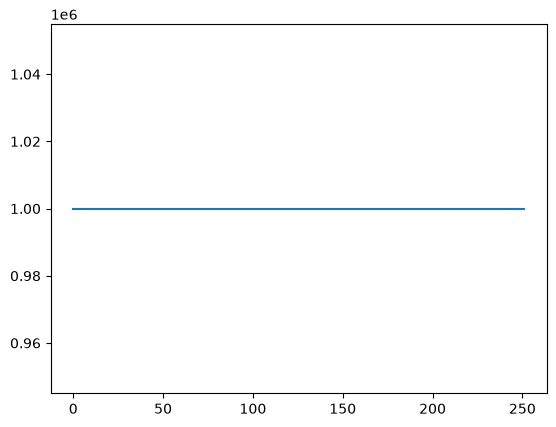

In [ ]:
%matplotlib inline
df_account_value.account_value.plot()

<a id='6.1'></a>
## 8.1 BackTestStats
pass in df_account_value, this information is stored in env class


In [ ]:

print("==============Get Backtest Results===========")
now = datetime.datetime.now().strftime('%Y%m%d-%Hh%M')

perf_stats_all = backtest_stats(account_value=df_account_value)
perf_stats_all = pd.DataFrame(perf_stats_all)
print(df_account_value.shape)

==============Get Backtest Results===========
Annual return          0.0
Cumulative returns     0.0
Annual volatility      0.0
Sharpe ratio           NaN
Calmar ratio           NaN
Stability              NaN
Max drawdown           0.0
Omega ratio            NaN
Sortino ratio          NaN
Skew                   NaN
Kurtosis               NaN
Tail ratio             NaN
Daily value at risk    0.0
dtype: float64
(252, 4)


In [ ]:
perf_stats_all.to_csv('Results ensemble model stats.csv')

In [ ]:
#baseline stats
print("==============Get Baseline Stats===========")
df_dji_ = get_baseline(
        ticker="^DJI", 
        start = df_account_value.loc[0,'date'],
        end = df_account_value.loc[len(df_account_value)-1,'date'])

stats = backtest_stats(df_dji_, value_col_name = 'close')

==============Get Baseline Stats===========
YF deprecation warning: set proxy via new config function: yf.set_config(proxy=proxy)


[*********************100%***********************]  1 of 1 completed

Shape of DataFrame:  (251, 8)
Annual return          0.070188
Cumulative returns     0.069900
Annual volatility      0.158069
Sharpe ratio           0.509637
Calmar ratio           0.373899
Stability              0.031916
Max drawdown          -0.187719
Omega ratio            1.095083
Sortino ratio          0.718813
Skew                        NaN
Kurtosis                    NaN
Tail ratio             0.749277
Daily value at risk   -0.019595
dtype: float64


In [ ]:
stats.to_csv('Results Baseline Stats.csv')

In [ ]:
df_dji = pd.DataFrame()
df_dji['date'] = df_account_value['date']
df_dji['dji'] = df_dji_['close'] / df_dji_['close'][0] * env_kwargs["initial_amount"]
print("df_dji: ", df_dji)
df_dji.to_csv("df_dji.csv")
df_dji = df_dji.set_index(df_dji.columns[0])
print("df_dji: ", df_dji)
df_dji.to_csv("df_dji+.csv")

df_account_value.to_csv('df_account_value.csv')


df_dji:             date           dji
0    2018-04-05  1.000000e+06
1    2018-04-06  9.766392e+05
2    2018-04-09  9.785302e+05
3    2018-04-10  9.960327e+05
4    2018-04-11  9.871141e+05
..          ...           ...
247  2019-03-29  1.058088e+06
248  2019-04-01  1.071544e+06
249  2019-04-02  1.068308e+06
250  2019-04-03  1.069900e+06
251  2019-04-04           NaN

[252 rows x 2 columns]
df_dji:                       dji
date                    
2018-04-05  1.000000e+06
2018-04-06  9.766392e+05
2018-04-09  9.785302e+05
2018-04-10  9.960327e+05
2018-04-11  9.871141e+05
...                  ...
2019-03-29  1.058088e+06
2019-04-01  1.071544e+06
2019-04-02  1.068308e+06
2019-04-03  1.069900e+06
2019-04-04           NaN

[252 rows x 1 columns]


<a id='6.2'></a>
## 8.2 BackTestPlot

df_result_ensemble.columns:  Index(['ensemble'], dtype='object')
df_trade_date:        datadate
0   2018-01-03
1   2018-01-04
2   2018-01-05
3   2018-01-08
4   2018-01-09
..         ...
349 2019-05-24
350 2019-05-28
351 2019-05-29
352 2019-05-30
353 2019-05-31

[354 rows x 1 columns]
df_result_ensemble:               ensemble
date                 
2018-04-05  1000000.0
2018-04-06  1000000.0
2018-04-09  1000000.0
2018-04-10  1000000.0
2018-04-11  1000000.0
...               ...
2019-03-29  1000000.0
2019-04-01  1000000.0
2019-04-02  1000000.0
2019-04-03  1000000.0
2019-04-04  1000000.0

[252 rows x 1 columns]
==============Compare to DJIA===========
result:               ensemble           dji
date                               
2018-04-05  1000000.0  1.000000e+06
2018-04-06  1000000.0  9.766392e+05
2018-04-09  1000000.0  9.785302e+05
2018-04-10  1000000.0  9.960327e+05
2018-04-11  1000000.0  9.871141e+05
...               ...           ...
2019-03-29  1000000.0  1.058088e+06
2019-04-01

<Figure size 1500x500 with 0 Axes>

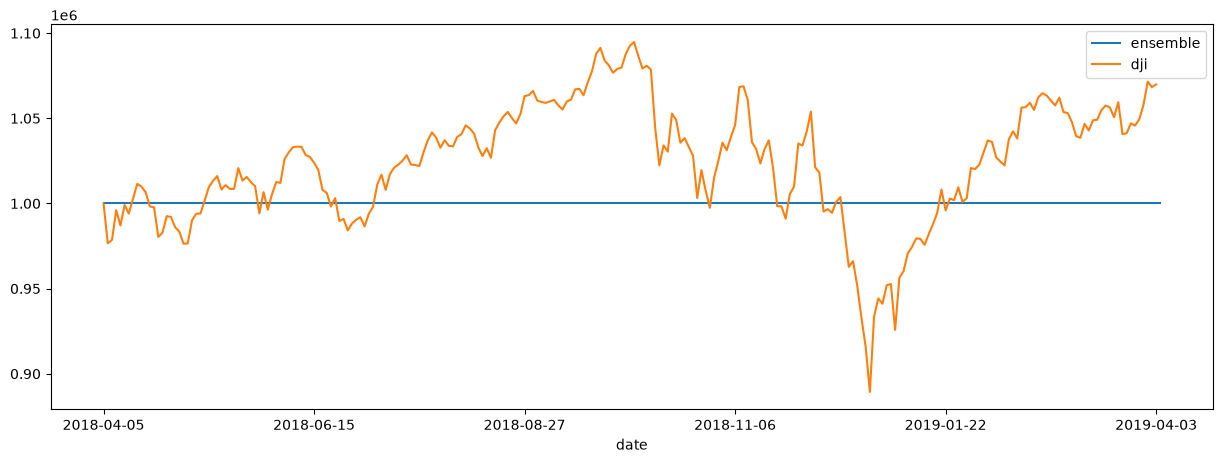

In [ ]:


# print("==============Compare to DJIA===========")
# %matplotlib inline
# # S&P 500: ^GSPC
# # Dow Jones Index: ^DJI
# # NASDAQ 100: ^NDX
# backtest_plot(df_account_value, 
#               baseline_ticker = '^DJI', 
#               baseline_start = df_account_value.loc[0,'date'],
#               baseline_end = df_account_value.loc[len(df_account_value)-1,'date'])
df.to_csv("df.csv")
df_result_ensemble = pd.DataFrame({'date': df_account_value['date'], 'ensemble': df_account_value['account_value']})
df_result_ensemble = df_result_ensemble.set_index('date')

print("df_result_ensemble.columns: ", df_result_ensemble.columns)

# df_result_ensemble.drop(df_result_ensemble.columns[0], axis = 1)
print("df_trade_date: ", df_trade_date)
# df_result_ensemble['date'] = df_trade_date['datadate']
# df_result_ensemble['account_value'] = df_account_value['account_value']
df_result_ensemble.to_csv("df_result_ensemble.csv")
print("df_result_ensemble: ", df_result_ensemble)
print("==============Compare to DJIA===========")
result = pd.DataFrame()
# result = pd.merge(result, df_result_ensemble, left_index=True, right_index=True)
# result = pd.merge(result, df_dji, left_index=True, right_index=True)
result = pd.merge(df_result_ensemble, df_dji, left_index=True, right_index=True)
print("result: ", result)
result.to_csv("result.csv")
result.columns = ['ensemble', 'dji']

%matplotlib inline
plt.rcParams["figure.figsize"] = (15,5)
plt.figure();
result.plot();

# 9. Saving the results

## 9.1 Save Experiment Outputs

Each experiment is saved with its configuration and performance outputs.

This is important because the project compares several specifications:

- technicals-only baseline,
- node-level network features,
- node-level plus market-level network features,
- different correlation thresholds.

Saving the configuration with each run makes the ablation analysis reproducible.

In [ ]:
from pathlib import Path
import json
from datetime import datetime

# =========================
# Create experiment folder
# =========================


timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = Path("results") / f"{cfg.RUN_NAME}_{timestamp}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

#RUN_NAME = f"B_threshold_{str(NETWORK_THRESHOLD).replace('.', '')}"
#RUN_NAME = 'Technicals_only_v1'


print(f"Saving results to: {OUTPUT_DIR}")

Saving results to: results\Test_20260714_190018


In [ ]:
config = {
    "debug": DEBUG,
    "network_threshold": NETWORK_THRESHOLD,
    "network_use_abs": NETWORK_USE_ABS,
    "use_network": USE_NETWORK,
    "use_market_network": USE_MARKET_NETWORK,
    "rebalance_window": REBALANCE_WINDOW,
    "validation_window": VALIDATION_WINDOW,
    "timesteps_dict": timesteps_dict,
    "final_indicators": FINAL_INDICATORS,
}

with open(OUTPUT_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=4, default=str)

perf_stats_all.to_csv(
    OUTPUT_DIR / "performance_stats.csv"
)

df_account_value.to_csv(
    OUTPUT_DIR / "account_value.csv",
    index=False
)

df_summary.to_csv(
    OUTPUT_DIR / "ensemble_summary.csv",
    index=False
)

if USE_NETWORK:
    network_df.to_csv(
        OUTPUT_DIR / "network_features.csv",
        index=False
    )
    FIG_DIR = OUTPUT_DIR / "figures"
    FIG_DIR.mkdir(exist_ok=True)

    plot_graph_at_date(
        rolling_corr,
        "2018-03-16",
        threshold=NETWORK_THRESHOLD,
        use_abs=NETWORK_USE_ABS,
        save_path=FIG_DIR / "network_2018_03_16.png"
    )

    plt.savefig(FIG_DIR / "network_2018_03_16.png",
                dpi=300,
                bbox_inches="tight",
            )

if USE_MARKET_NETWORK:
    average_measures_date.to_csv(
        OUTPUT_DIR / "market_network_metrics.csv",
        index=False
    )

NameError: name 'DEBUG' is not defined

In [ ]:
# Final experiment settings
print(RUN_NAME)
print(DEBUG)
print(NETWORK_THRESHOLD)
print(USE_NETWORK)
print(USE_MARKET_NETWORK)

# 10. Reporting and Comparison of Saved Runs

This section is for after-the-fact reporting.

It loads saved experiment outputs and compares the baseline model against the network-extended versions. This section is not required to train a new model, but it is useful for producing the final tables used in the report.

In [ ]:
#Please note that the paths in each of the following loads will vary depending on your existing files.

baseline = pd.read_csv(
    "results/Technicals_only_v1_20260602_080137/account_value.csv"
)

network_only_node = pd.read_csv(
    "results/B_threshold_05_v1_20260602_141906/account_value.csv"
)

network_full = pd.read_csv(
    "results/network_v1_20260602_031641/account_value.csv"
)

dji = pd.read_csv(
    "df_dji+.csv"
)

plt.figure(figsize=(13,6))

plt.plot(
    pd.to_datetime(baseline["date"]),
    baseline["account_value"],
    label="Technical Indicators",
    linewidth=2
)

plt.plot(
    pd.to_datetime(network_only_node["date"]),
    network_only_node["account_value"],
    label="Node Features Only",
    linewidth=2
)

plt.plot(
    pd.to_datetime(network_full["date"]),
    network_full["account_value"],
    label="Full Network",
    linewidth=2
)

plt.plot(
    pd.to_datetime(dji["date"]),
    dji["dji"],
    label="DJI",
    linewidth=2
)

plt.title("Portfolio Value Comparison (Run 1)", fontsize=14)

plt.xlabel("Date", fontsize=12)
plt.ylabel("Portfolio Value", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.legend(
    fontsize=10,
    loc="upper left"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "portfolio_comparison_run1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
baseline = pd.read_csv(
    "results/Technicals_only_v2_20260606_203155/account_value.csv"
)


network_only_node = pd.read_csv(
    "results/B_threshold_05_v2_20260606_121807/account_value.csv"
)

network_full = pd.read_csv(
    "results/Network_v2_20260607_221936/account_value.csv"
)

dji = pd.read_csv(
    "df_dji+.csv"
)

plt.figure(figsize=(13,6))

plt.plot(
    pd.to_datetime(baseline["date"]),
    baseline["account_value"],
    label="Technical Indicators",
    linewidth=2
)

plt.plot(
    pd.to_datetime(network_only_node["date"]),
    network_only_node["account_value"],
    label="Node Features Only",
    linewidth=2
)

plt.plot(
    pd.to_datetime(network_full["date"]),
    network_full["account_value"],
    label="Full Network",
    linewidth=2
)

plt.plot(
    pd.to_datetime(dji["date"]),
    dji["dji"],
    label="DJI",
    linewidth=2
)

plt.title("Portfolio Value Comparison (Run 2)", fontsize=14)

plt.xlabel("Date", fontsize=12)
plt.ylabel("Portfolio Value", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.legend(
    fontsize=10,
    loc="upper left"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "portfolio_comparison_run2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
RESULTS_DIR = Path("results")

rows = []

for run_dir in RESULTS_DIR.iterdir():
    if not run_dir.is_dir():
        continue

    config_path = run_dir / "config.json"
    stats_path = run_dir / "performance_stats.csv"

    if not config_path.exists() or not stats_path.exists():
        continue

    with open(config_path, "r") as f:
        config = json.load(f)

    stats = pd.read_csv(stats_path, index_col=0)

    row = {
        "run_name": run_dir.name,
        "use_network": config.get("use_network"),
        "use_market_network": config.get("use_market_network"),
        "network_threshold": config.get("network_threshold"),
        "network_use_abs": config.get("network_use_abs"),
        "rebalance_window": config.get("rebalance_window"),
        "validation_window": config.get("validation_window"),
    }

    for metric in stats.index:
        row[metric] = stats.loc[metric].values[0]

    rows.append(row)

comparison_df = pd.DataFrame(rows)
comparison_df

comparison_df.sort_values("Sharpe ratio", ascending=False)

comparison_df = comparison_df[
    [
        "run_name",
        "Cumulative returns",
        "Annual return",
        "Annual volatility",
        "Sharpe ratio",
        "Calmar ratio",
        "Stability",
        "Omega ratio",
        "Sortino ratio",
        "Tail ratio",
        "Daily value at risk",
        "Max drawdown"
    ]
]
comparison_df_original= comparison_df.copy()
comparison_df = comparison_df[
    (comparison_df["run_name"] != "B_threshold_04_20260605_202909") & (comparison_df["run_name"] != "B_threshold_06_20260606_071045")
]

comparison_df

In [ ]:
# Build grouped comparison tables.
technicals_df = comparison_df[
    comparison_df["run_name"].str.contains("Technicals_only")
]

network__full_df = comparison_df[
    comparison_df["run_name"].str.contains("Network")
]

network_node_only_df = comparison_df[
    comparison_df["run_name"].str.contains("B_threshold")
]


numeric_cols = comparison_df.select_dtypes(include="number").columns

technicals_mean = technicals_df[numeric_cols].mean()

network_full_mean = network__full_df[numeric_cols].mean()

network_node_only_mean = network_node_only_df[numeric_cols].mean()


summary_df = pd.DataFrame([
    technicals_mean,
    network_full_mean,
    network_node_only_mean
])

summary_df.index = [
    "Technicals Mean",
    "Node Only Network Mean",
    "Full Network Mean"
]


summary_df = pd.concat([
    technicals_df,
    network__full_df,
    network_node_only_df,
    pd.DataFrame([
        {
            "run_name": "Technicals Mean",
            **technicals_mean.to_dict()
        },
        {
            "run_name": "Network Mean",
            **network_full_mean.to_dict()
        },
        {
            "run_name": "B_threshold Mean",
            **network_node_only_mean.to_dict()
        }
    ])
])

In [ ]:
summary_df = summary_df.sort_values("run_name")
technicals_df = summary_df[
    summary_df["run_name"].str.contains("Technicals", case=False)
].sort_values("run_name")

network_full_df = summary_df[
    summary_df["run_name"].str.contains("Network", case=False)
].sort_values("run_name")

network_node_only_df = summary_df[
    summary_df["run_name"].str.contains("B_threshold", case=False)
].sort_values("run_name")


In [ ]:
print("=== TECHNICALS ===")
display(technicals_df)

print("=== NODE ONLY NETWORK ===")
display(network_node_only_df)

print("=== FULL NETWORK ===")
display(network_full_df)

## 10.1 Threshold Analysis reporting

Threshold 0.4 and 0.6 are based on one run; threshold 0.5 uses the main node-level runs.

In [ ]:
comparison_df_original

In [ ]:
Threshold_analysis= comparison_df_original[
    comparison_df_original["run_name"].str.contains("B_threshold")
]
Threshold_analysis

In [ ]:
Network_04 = pd.read_csv(
    "results/B_threshold_04_20260605_202909/account_value.csv"
)

Network_05 = pd.read_csv(
    "results/B_threshold_05_v1_20260602_141906/account_value.csv"
)

Network_06 = pd.read_csv(
    "results/B_threshold_06_20260606_071045/account_value.csv"
)

dji = pd.read_csv(
    "df_dji+.csv"
)

plt.figure(figsize=(12,6))

plt.plot(
    pd.to_datetime(Network_04["date"]),
    Network_04["account_value"],
    label="Network threshold=0.4"
)

plt.plot(
    pd.to_datetime(Network_05["date"]),
    Network_05["account_value"],
    label="Network threshold=0.5"
)

plt.plot(
    pd.to_datetime(Network_06["date"]),
    Network_06["account_value"],
    label="Network threshold=0.6"
)

plt.plot(
    pd.to_datetime(dji["date"]),
    dji["dji"],
    label="DJI"
)

plt.legend()
plt.title("Portfolio Value Comparison")
plt.ylabel("Portfolio Value ($)")
plt.xlabel("Date")
plt.grid(True)
plt.show()